<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/01_Clasificación_Bayesiana/perceptron_pocket.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [41]:
###########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)                #
# E-mail: wgomez@cinvestav.mx                             #
# Curso: Análisis de datos                                #
# Tópico: Algoritmo perceptrón pocket                     #
###########################################################

Carga biblioteca necesarias

In [42]:
import numpy as np
import matplotlib.pyplot as plt

Genera conjunto de datos no linealmente separables con dos clases

In [43]:
c1 = np.array([[0.70, 0.90],
               [0.60, 0.70],
               [0.65, 0.35],
               [0.90, 0.20],
               [0.75, 0.60],
               [0.45, 0.39]]).T # Clase 1

c2 = np.array([[0.30, 0.70],
               [0.20, 0.57],
               [0.25, 0.30],
               [0.10, 0.20],
               [0.40, 0.45],
               [0.70, 0.62]]).T # Clase 2

d = c1.shape[0] # Número de variables
n = c1.shape[1] + c2.shape[1] # Número de muestras

Aumenta los vectores a dimensionalidad $d+1$ para cálculo del desvío e invierte el signo de una de las clases para encontrar una solución tal que $\mathbf{w}^T \mathbf{x}_i > 0, \; \forall i$

In [44]:
x1 = np.vstack([np.ones((1, c1.shape[1])), c1]) # Clase 1 aumentada a d+1
x2 = -np.vstack([np.ones((1, c2.shape[1])), c2]) # Clase 2 aumentada a d+1 e invertida
x = np.hstack([x1, x2]) # Conjunto de datos completo

Entrenamiento del vector de pesos $\mathbf{w}$ usando el algoritmo perceptón pocket

In [45]:
W = np.zeros((d + 1, 1))  # Inicializa vector de pesos
Wp = np.zeros((d + 1, 1)) # Inicializa vector pocket
hp = 0  # Contador de casos clasificados correctamente
eta = 1 # Tasa de aprendizaje
t = 0 # Contador de iteraciones
tmax = 10000  # Número máximo de iteraciones
while (t < tmax) and (hp < n):
    t = t + 1
    id = (W.T @ x <= 0).flatten() # Casos mal clasificados con el vector de pesos actual
    W = W + eta * np.sum(x[:, id], axis=1, keepdims=True) # Actualiza el vector de pesos
    h = np.sum((W.T @ x) > 0) # Casos correctamente clasificados con el vector de pesos actualizado
    if h > hp:  # Si aumenta el número de casos correctamente clasificados
        Wp = W.copy() # Guarda el vector de pesos actual en el pocket
        hp = h  # Actualiza el contador

print("Vector de pesos pocket:")
print(Wp)

Vector de pesos pocket:
[[-4.  ]
 [10.4 ]
 [-1.42]]


Grafica la frontera de desición generada por el vector de pesos $\mathbf{w}$

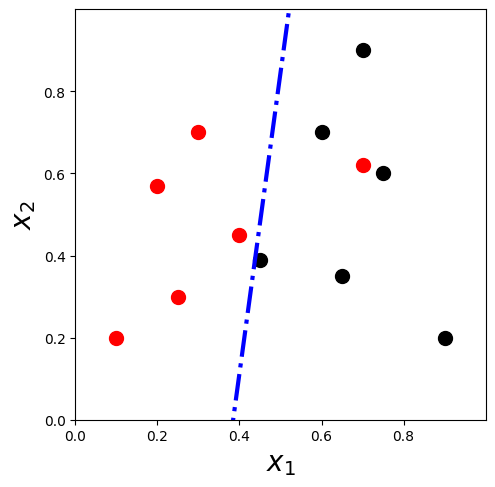

In [46]:
xx = np.arange(-1, 1, 0.05)
yy = (-Wp[0, 0] - xx * Wp[1, 0]) / Wp[2, 0] # Frontera de decisión

fig = plt.figure(facecolor='white', figsize=(5.33, 5.33))
ax = fig.add_subplot(111)
ax.plot(c1[0, :], c1[1, :], 'ko', markerfacecolor='k', markersize=10, label='c1')
ax.plot(c2[0, :], c2[1, :], 'o', markeredgecolor='r', markerfacecolor='r', markersize=10, label='c2')
ax.plot(xx, yy, color='b', linestyle='-.', linewidth=3)
ax.set_xticks(np.arange(0, 1, 0.2))
ax.set_yticks(np.arange(0, 1, 0.2))
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('$x_1$', fontsize=20)
ax.set_ylabel('$x_2$', fontsize=20)
plt.show()